In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, f1_score,precision_score, recall_score,confusion_matrix, ConfusionMatrixDisplay

In [71]:
df_Scylla = pd.read_csv("Relatório_Pibic_2026/Extrator_ArqPy/resultados/scylla/scylla_per_file.csv")
df_DPy = pd.read_csv("Relatório_Pibic_2026/Extrator_ArqPy/resultados/dpy/dpy_per_file.csv")
df_PyExamine = pd.read_csv("Relatório_Pibic_2026/Extrator_ArqPy/resultados/pyexamine/pyexamine_per_file.csv")
df_SonarQube = pd.read_csv("Relatório_Pibic_2026/Extrator_ArqPy/resultados/sonarqube/sonar_per_file.csv")
df_experts = pd.read_csv("Relatório_Pibic_2026/Extrator_ArqPy/resultados/experts_ground_truth.csv")

In [72]:
df_experts.head();

In [73]:
df_Scylla.head();

In [74]:
df_DPy.head();

In [75]:
df_PyExamine.head();

In [76]:
df_SonarQube.head();

In [77]:
scylla_long_method = (df_Scylla["scylla_long_method"]== 1).sum()
scylla_long_parameter_list = (df_Scylla["scylla_long_parameter_list"]== 1).sum()
dpy_long_method = (df_DPy["dpy_long_method"]== 1).sum()
dpy_long_parameter_list = (df_DPy["dpy_long_parameter_list"]== 1).sum()
pyexamine_long_method = (df_PyExamine["pyexamine_long_method"]== 1).sum()
pyexamine_long_parameter_list = (df_PyExamine["pyexamine_long_parameter_list"]== 1).sum()
sonar_long_method = (df_SonarQube["sonar_long_method"]== 1).sum()
sonar_long_parameter_list = (df_SonarQube["sonar_long_parameter_list"]== 1).sum()
expert_long_method = (df_experts["expert_long_method"]== 1).sum()
expert_long_parameter_list = (df_experts["expert_long_parameter_list"]== 1).sum()

scylla_total = (
    (df_Scylla["scylla_long_method"] == 1) &
    (df_Scylla["scylla_long_parameter_list"] == 1)
).sum()

dpy_total = (
    (df_DPy["dpy_long_method"] == 1) &
    (df_DPy["dpy_long_parameter_list"] == 1)
).sum()

pyexamine_total = (
    (df_PyExamine["pyexamine_long_method"] == 1) &
    (df_PyExamine["pyexamine_long_parameter_list"] == 1)
).sum()

sonar_total = (
    (df_SonarQube["sonar_long_method"] == 1) &
    (df_SonarQube["sonar_long_parameter_list"] == 1)
).sum()

expert_total = (
    (df_experts["expert_long_method"] == 1) &
    (df_experts["expert_long_parameter_list"] == 1)
).sum()

print("Ocorrências em Scylla:")
print("Long Method -",scylla_long_method)
print("Long Parameter List -",scylla_long_parameter_list)
print()
print("Ocorrências em DPy:")
print("Long Method -",dpy_long_method)
print("Long Parameter List -",dpy_long_parameter_list)
print()
print("Ocorrências em PyExamine:")
print("Long Method -",pyexamine_long_method)
print("Long Parameter List -",pyexamine_long_parameter_list)
print()
print("Ocorrências em SonarQuber:")
print("Long Method -",sonar_long_method)
print("Long Parameter List -",sonar_long_parameter_list)

Ocorrências em Scylla:
Long Method - 25
Long Parameter List - 170

Ocorrências em DPy:
Long Method - 87
Long Parameter List - 93

Ocorrências em PyExamine:
Long Method - 87
Long Parameter List - 0

Ocorrências em SonarQuber:
Long Method - 147
Long Parameter List - 26


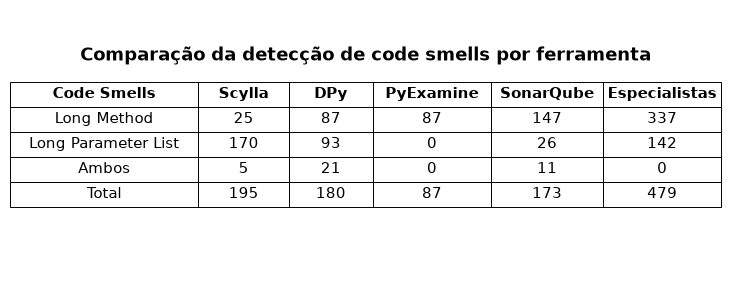

In [123]:
tabela = pd.DataFrame({
    "Code Smells": [
        "Long Method",
        "Long Parameter List",
        "Ambos",
        "Total"
    ],

    "Scylla": [
        scylla_long_method,
        scylla_long_parameter_list,
        scylla_total,
        scylla_long_method + scylla_long_parameter_list
    ],

    "DPy": [
        dpy_long_method,
        dpy_long_parameter_list,
        dpy_total,
        dpy_long_method + dpy_long_parameter_list
    ],

    "PyExamine": [
        pyexamine_long_method,
        pyexamine_long_parameter_list,
        pyexamine_total,
        pyexamine_long_method + pyexamine_long_parameter_list
    ],

    "SonarQube": [
        sonar_long_method,
        sonar_long_parameter_list,
        sonar_total,
        sonar_long_method + sonar_long_parameter_list
    ],

    "Especialistas": [
        expert_long_method,
        expert_long_parameter_list,
        expert_total,
        expert_long_method + expert_long_parameter_list
    ]
})

fig, ax = plt.subplots(figsize=(9, 3.5))

ax.axis("off")



ax.set_title(
    "Comparação da detecção de code smells por ferramenta", 
    fontsize=13, 
    weight="bold", 
    y=0.78  
)

tabela_plot = ax.table(
    cellText=tabela.values,
    colLabels=tabela.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",

    colWidths=[
        0.27,
        0.13,
        0.12,
        0.17,
        0.16,
        0.17
    ]
)

tabela_plot.auto_set_font_size(False)
tabela_plot.set_fontsize(10.5)
tabela_plot.scale(1, 1.5)


for (row, col), cell in tabela_plot.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")


for cell in tabela_plot.get_celld().values():
    cell.set_linewidth(0.7)


plt.savefig(
    "Deteccoes.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2
)

plt.show()

In [95]:
ScDPy_LongMethods = cohen_kappa_score(
    df_Scylla["scylla_long_method"],
    df_DPy["dpy_long_method"]
)
ScDPy_LongParameterList = cohen_kappa_score(
    df_Scylla["scylla_long_parameter_list"],
    df_DPy["dpy_long_parameter_list"]
)

ScPE_LongMethods = cohen_kappa_score(
    df_Scylla["scylla_long_method"],
    df_PyExamine["pyexamine_long_method"]
)
ScPE_LongParameterList = cohen_kappa_score(
    df_Scylla["scylla_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"]
)

ScSo_LongMethods = cohen_kappa_score(
    df_Scylla["scylla_long_method"],
    df_SonarQube["sonar_long_method"]
)
ScSo_LongParameterList = cohen_kappa_score(
    df_Scylla["scylla_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"]
)

DPyPE_LongMethods = cohen_kappa_score(
    df_DPy["dpy_long_method"],
    df_PyExamine["pyexamine_long_method"]
)
DPyPE_LongParameterList = cohen_kappa_score(
    df_DPy["dpy_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"]
)

DPySo_LongMethods = cohen_kappa_score(
    df_DPy["dpy_long_method"],
    df_SonarQube["sonar_long_method"]
)
DPySo_LongParameterList = cohen_kappa_score(
    df_DPy["dpy_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"]
)

PESo_LongMethods = cohen_kappa_score(
    df_PyExamine["pyexamine_long_method"],
    df_SonarQube["sonar_long_method"]
)
PESo_LongParameterList = cohen_kappa_score(
    df_PyExamine["pyexamine_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"]
)

ScDPy_average = (ScDPy_LongMethods + ScDPy_LongParameterList)/2
ScPE_average = (ScPE_LongMethods + ScPE_LongParameterList)/2
ScSo_average = (ScSo_LongMethods + ScSo_LongParameterList)/2
DPyPE_average = (DPyPE_LongMethods + DPyPE_LongParameterList)/2
DPySo_average = (DPySo_LongMethods + DPySo_LongParameterList)/2
PESo_average = (PESo_LongMethods + PESo_LongParameterList)/2

print("Coeficiente de Kappa entre Scylla e DPy:")
print(f"Long Methods - {ScDPy_LongMethods: .2f}")
print(f"Long Parameter List - {ScDPy_LongParameterList: .2f}")
print()

print("Coeficiente de Kappa entre Scylla e PyExamine:")
print(f"Long Methods - {ScPE_LongMethods: .2f}")
print(f"Long Parameter List - {ScPE_LongParameterList: .2f}")
print()

print("Coeficiente de Kappa entre Scylla e SonarQube:")
print(f"Long Methods - {ScSo_LongMethods: .2f}")
print(f"Long Parameter List - {ScSo_LongParameterList: .2f}")
print()

print("Coeficiente de Kappa entre DPy e PyExamine:")
print(f"Long Methods - {DPyPE_LongMethods: .2f}")
print(f"Long Parameter List - {DPyPE_LongParameterList: .2f}")
print()

print("Coeficiente de Kappa entre DPy e SonarQube:")
print(f"Long Methods - {DPySo_LongMethods: .2f}")
print(f"Long Parameter List - {DPySo_LongParameterList: .2f}")
print()

print("Coeficiente de Kappa entre PyExamine e SonarQube:")
print(f"Long Methods - {PESo_LongMethods: .2f}")
print(f"Long Parameter List - {PESo_LongParameterList: .2f}")


Coeficiente de Kappa entre Scylla e DPy:
Long Methods -  0.37
Long Parameter List -  0.66

Coeficiente de Kappa entre Scylla e PyExamine:
Long Methods -  0.42
Long Parameter List -  0.00

Coeficiente de Kappa entre Scylla e SonarQube:
Long Methods -  0.26
Long Parameter List -  0.23

Coeficiente de Kappa entre DPy e PyExamine:
Long Methods -  0.82
Long Parameter List -  0.00

Coeficiente de Kappa entre DPy e SonarQube:
Long Methods -  0.65
Long Parameter List -  0.31

Coeficiente de Kappa entre PyExamine e SonarQube:
Long Methods -  0.62
Long Parameter List -  0.00


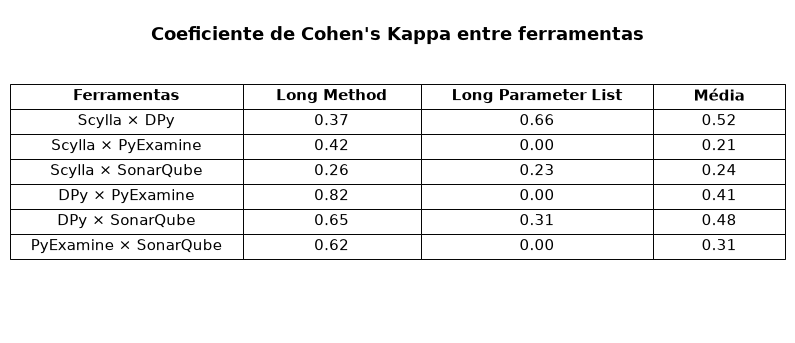

In [98]:
kappa_table = pd.DataFrame({
    "Ferramentas": [
        "Scylla × DPy",
        "Scylla × PyExamine",
        "Scylla × SonarQube",
        "DPy × PyExamine",
        "DPy × SonarQube",
        "PyExamine × SonarQube"
    ],
    
    "Long Method": [
        ScDPy_LongMethods,
        ScPE_LongMethods,
        ScSo_LongMethods,
        DPyPE_LongMethods,
        DPySo_LongMethods,
        PESo_LongMethods
    ],
    
    "Long Parameter List": [
        ScDPy_LongParameterList,
        ScPE_LongParameterList,
        ScSo_LongParameterList,
        DPyPE_LongParameterList,
        DPySo_LongParameterList,
        PESo_LongParameterList
    ],
    "Média": [
        ScDPy_average,
        ScPE_average,
        ScSo_average,
        DPyPE_average,
        DPySo_average,
        PESo_average,
    ],
})

# Criar uma cópia para não alterar a tabela original
kappa_table_display = kappa_table.copy()

# Formatar os coeficientes com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    kappa_table_display[col] = kappa_table_display[col].apply(
        lambda x: f"{x:.2f}"
    )

# Criar figura com tamanho padronizado
fig, ax = plt.subplots(figsize=(10, 4.2))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Coeficiente de Cohen's Kappa entre ferramentas", 
    fontsize=13, 
    weight="bold", 
    y=0.88  # Posiciona perfeitamente acima da tabela
)

# Criar tabela
table = ax.table(
    cellText=kappa_table_display.values,
    colLabels=kappa_table_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.30, 0.23, 0.30, 0.17]
)

# Configuração da fonte
table.auto_set_font_size(False)
table.set_fontsize(10.5)

# Escalamento das linhas (mesmo padrão das outras)
table.scale(1, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Espessura das bordas
for cell in table.get_celld().values():
    cell.set_linewidth(0.7)

# Salvar como JPEG
plt.savefig(
    "cohen_kappa_between_tools.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

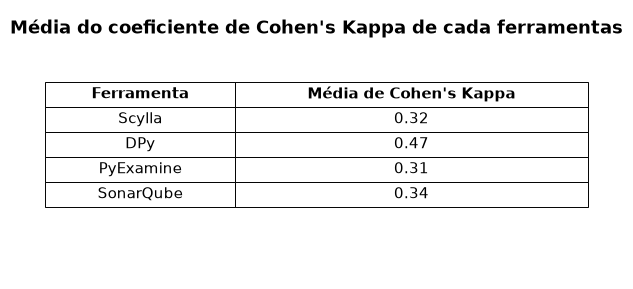

In [121]:
Sy_average = (ScDPy_average + ScPE_average + ScSo_average)/3
DPy_average = (ScDPy_average + DPyPE_average + DPySo_average)/3
PE_average = (ScPE_average + DPyPE_average + PESo_average)/3
So_average = (ScSo_average + DPySo_average + PESo_average)/3

# Criar tabela com a média de Kappa de cada ferramenta
kappa_average_table = pd.DataFrame({
    "Ferramenta": [
        "Scylla",
        "DPy",
        "PyExamine",
        "SonarQube"
    ],
    
    "Média de Cohen's Kappa": [
        Sy_average,
        DPy_average,
        PE_average,
        So_average
    ]
})

# Criar uma cópia para exibição
kappa_average_display = kappa_average_table.copy()

# Formatar os valores com 2 casas decimais
kappa_average_display["Média de Cohen's Kappa"] = (
    kappa_average_display["Média de Cohen's Kappa"]
    .apply(lambda x: f"{x:.2f}")
)

# Criar figura
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.axis("off")

ax.set_title(
    "Média do coeficiente de Cohen's Kappa de cada ferramentas", 
    fontsize=13, 
    weight="bold", 
    y=0.88  # Posiciona perfeitamente acima da tabela
)

# Criar tabela
table = ax.table(
    cellText=kappa_average_display.values,
    colLabels=kappa_average_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    
    # Platform | Average Cohen's Kappa
    colWidths=[
        0.35,
        0.65
    ]
)

# Configuração da fonte
table.auto_set_font_size(False)
table.set_fontsize(11)

# Ajustar tamanho das células
table.scale(1, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Espessura das bordas
for cell in table.get_celld().values():
    cell.set_linewidth(0.7)

# Salvar como JPEG
plt.savefig(
    "cohen_kappa_average.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()


In [100]:
ScEx_LongMethods = cohen_kappa_score(
    df_Scylla["scylla_long_method"],
    df_experts["expert_long_method"]
)
ScEx_LongParameterList = cohen_kappa_score(
    df_Scylla["scylla_long_parameter_list"],
    df_experts["expert_long_parameter_list"]
)

DPyEx_LongMethods = cohen_kappa_score(
    df_DPy["dpy_long_method"],
    df_experts["expert_long_method"]
)
DPyEx_LongParameterList = cohen_kappa_score(
    df_DPy["dpy_long_parameter_list"],
    df_experts["expert_long_parameter_list"]
)

PEEx_LongMethods = cohen_kappa_score(
    df_PyExamine["pyexamine_long_method"],
    df_experts["expert_long_method"]
)
PEEx_LongParameterList = cohen_kappa_score(
    df_PyExamine["pyexamine_long_parameter_list"],
    df_experts["expert_long_parameter_list"]
)

SoEx_LongMethods = cohen_kappa_score(
    df_SonarQube["sonar_long_method"],
    df_experts["expert_long_method"]
)
SoEx_LongParameterList = cohen_kappa_score(
    df_SonarQube["sonar_long_parameter_list"],
    df_experts["expert_long_parameter_list"]
)

ScEx_average = (ScEx_LongMethods + ScEx_LongParameterList)/2
DPyEx_average = (DPyEx_LongMethods + DPyEx_LongParameterList)/2
PEEx_average = (PEEx_LongMethods + PEEx_LongParameterList)/2
SoEx_average = (SoEx_LongMethods + SoEx_LongParameterList)/2

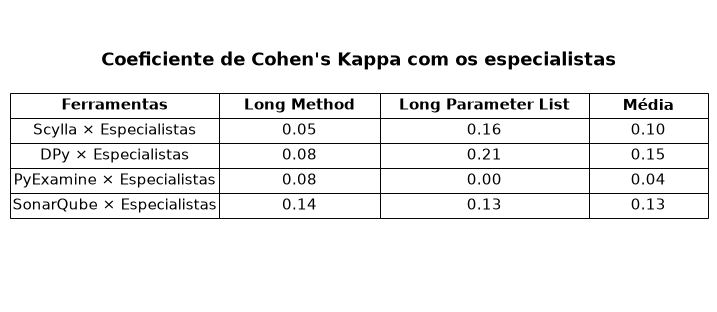

In [133]:
kappa_expert_table = pd.DataFrame({
    "Ferramentas": [
        "Scylla × Especialistas",
        "DPy × Especialistas",
        "PyExamine × Especialistas",
        "SonarQube × Especialistas"
    ],
    
    "Long Method": [
        ScEx_LongMethods,
        DPyEx_LongMethods,
        PEEx_LongMethods,
        SoEx_LongMethods,
    ],
    
    "Long Parameter List": [
        ScEx_LongParameterList,
        DPyEx_LongParameterList,
        PEEx_LongParameterList,
        SoEx_LongParameterList
    ],

    "Média": [
        ScEx_average,
        DPyEx_average,
        PEEx_average,
        SoEx_average
    ],
})

# Criar uma cópia para não alterar a tabela original
kappa_expert_table_display = kappa_expert_table.copy()

# Formatar os coeficientes com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    kappa_expert_table_display[col] = kappa_expert_table_display[col].apply(
        lambda x: f"{x:.2f}"
    )

# Criar figura (altura ajustada ligeiramente para acomodar o título)
fig, ax = plt.subplots(figsize=(9, 3.8))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Coeficiente de Cohen's Kappa com os especialistas", 
    fontsize=13, 
    weight="bold", 
    y=0.78  # Posiciona o título logo acima do cabeçalho da tabela
)

# Criar tabela
table = ax.table(
    cellText=kappa_expert_table_display.values,
    colLabels=kappa_expert_table_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",

    # Largura de cada coluna
    colWidths=[
        0.30,   # Platforms
        0.23,   # Long Method
        0.30,   # Long Parameter List
        0.17    # Average
    ]
)

# Configuração da fonte
table.auto_set_font_size(False)
table.set_fontsize(10.5)

# Aumentar altura das linhas
table.scale(1, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Espessura das bordas
for cell in table.get_celld().values():
    cell.set_linewidth(0.7)

# Salvar como JPEG
plt.savefig(
    "cohen_kappa_with_experts.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem adequada nas bordas superiores
)

plt.show()

In [131]:
# Long Method

po_ScDPy_LongMethod = (
    df_Scylla["scylla_long_method"] == 
    df_DPy["dpy_long_method"]
).mean()

po_ScPE_LongMethod = (
    df_Scylla["scylla_long_method"] == 
    df_PyExamine["pyexamine_long_method"]
).mean()

po_ScSo_LongMethod = (
    df_Scylla["scylla_long_method"] == 
    df_SonarQube["sonar_long_method"]
).mean()

po_DPyPE_LongMethod = (
    df_DPy["dpy_long_method"] == 
    df_PyExamine["pyexamine_long_method"]
).mean()

po_DPySo_LongMethod = (
    df_DPy["dpy_long_method"] == 
    df_SonarQube["sonar_long_method"]
).mean()

po_PESo_LongMethod = (
    df_PyExamine["pyexamine_long_method"] == 
    df_SonarQube["sonar_long_method"]
).mean()


# Long Parameter List

po_ScDPy_LongParameterList = (
    df_Scylla["scylla_long_parameter_list"] == 
    df_DPy["dpy_long_parameter_list"]
).mean()

po_ScPE_LongParameterList = (
    df_Scylla["scylla_long_parameter_list"] == 
    df_PyExamine["pyexamine_long_parameter_list"]
).mean()

po_ScSo_LongParameterList = (
    df_Scylla["scylla_long_parameter_list"] == 
    df_SonarQube["sonar_long_parameter_list"]
).mean()

po_DPyPE_LongParameterList = (
    df_DPy["dpy_long_parameter_list"] == 
    df_PyExamine["pyexamine_long_parameter_list"]
).mean()

po_DPySo_LongParameterList = (
    df_DPy["dpy_long_parameter_list"] == 
    df_SonarQube["sonar_long_parameter_list"]
).mean()

po_PESo_LongParameterList = (
    df_PyExamine["pyexamine_long_parameter_list"] == 
    df_SonarQube["sonar_long_parameter_list"]
).mean()

po_ScSo = (po_ScDPy_LongMethod + po_ScDPy_LongParameterList)/2
po_ScDPy = (po_ScPE_LongMethod + po_ScPE_LongParameterList)/2
po_ScPE = (po_ScSo_LongMethod + po_ScSo_LongParameterList)/2
po_DPyPE = (po_DPyPE_LongMethod + po_DPyPE_LongParameterList)/2
po_DPySo = (po_DPySo_LongMethod + po_DPySo_LongParameterList)/2
po_PESo = (po_PESo_LongMethod + po_PESo_LongParameterList)/2

po_table = pd.DataFrame({
    "Ferramentas": [
        "Scylla × DPy",
        "Scylla × PyExamine",
        "Scylla × SonarQube",
        "DPy × PyExamine",
        "DPy × SonarQube",
        "PyExamine × SonarQube"
    ],

    "Long Method": [
        po_ScDPy_LongMethod,
        po_ScPE_LongMethod,
        po_ScSo_LongMethod,
        po_DPyPE_LongMethod,
        po_DPySo_LongMethod,
        po_PESo_LongMethod,
    ],

    "Long Parameter List": [
        po_ScDPy_LongParameterList,
        po_ScPE_LongParameterList,
        po_ScSo_LongParameterList,
        po_DPyPE_LongParameterList,
        po_DPySo_LongParameterList,
        po_PESo_LongParameterList,
    ],

    "Média":[
        po_ScSo,
        po_ScDPy,
        po_ScPE,
        po_DPyPE,
        po_DPySo,
        po_PESo,
    ]
})


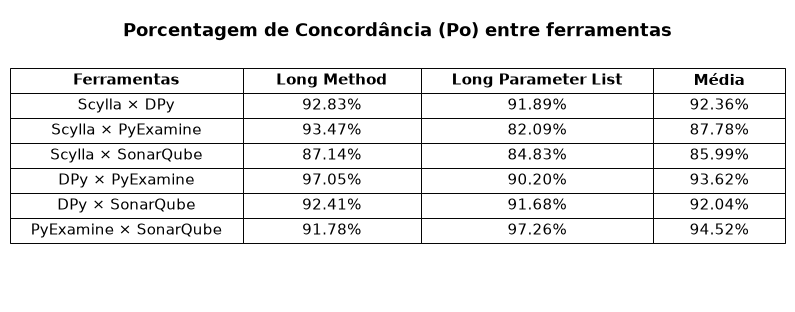

In [132]:
# Criar uma cópia para não alterar a tabela original
po_table_display = po_table.copy()

# Formatar como porcentagem com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    po_table_display[col] = po_table_display[col].apply(
        lambda x: f"{x * 100:.2f}%"
    )

# Criar figura (altura ajustada para 3.8 para acomodar o título com folga)
fig, ax = plt.subplots(figsize=(10, 3.8))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Porcentagem de Concordância (Po) entre ferramentas", 
    fontsize=13, 
    weight="bold", 
    y=0.88  # Posiciona o título logo acima do cabeçalho da tabela
)

# Criar tabela
table = ax.table(
    cellText=po_table_display.values,
    colLabels=po_table_display.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",

    # Mesma proporção visual da tabela anterior
    colWidths=[
        0.30,   # Platforms
        0.23,   # Long Method
        0.30,   # Long Parameter List
        0.17    # Average
    ]
)

# Configuração da fonte
table.auto_set_font_size(False)
table.set_fontsize(10.5)

# Altura das linhas
table.scale(1, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Espessura das bordas
for cell in table.get_celld().values():
    cell.set_linewidth(0.7)

# Salvar como JPEG
plt.savefig(
    "percentage_agreement_between_tools.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem adequada para o título
)

plt.show()

In [137]:
# =========================
# Percentage Agreement
# Expert × Ferramentas
# =========================

# Long Method

po_ExpertScylla_LongMethod = (
    df_experts["expert_long_method"] ==
    df_Scylla["scylla_long_method"]
).mean()

po_ExpertDPy_LongMethod = (
    df_experts["expert_long_method"] ==
    df_DPy["dpy_long_method"]
).mean()

po_ExpertPyExamine_LongMethod = (
    df_experts["expert_long_method"] ==
    df_PyExamine["pyexamine_long_method"]
).mean()

po_ExpertSonarQube_LongMethod = (
    df_experts["expert_long_method"] ==
    df_SonarQube["sonar_long_method"]
).mean()


# Long Parameter List

po_ExpertScylla_LongParameterList = (
    df_experts["expert_long_parameter_list"] ==
    df_Scylla["scylla_long_parameter_list"]
).mean()

po_ExpertDPy_LongParameterList = (
    df_experts["expert_long_parameter_list"] ==
    df_DPy["dpy_long_parameter_list"]
).mean()

po_ExpertPyExamine_LongParameterList = (
    df_experts["expert_long_parameter_list"] ==
    df_PyExamine["pyexamine_long_parameter_list"]
).mean()

po_ExpertSonarQube_LongParameterList = (
    df_experts["expert_long_parameter_list"] ==
    df_SonarQube["sonar_long_parameter_list"]
).mean()


# =========================
# Média dos dois smells
# =========================

po_ExpertScylla = (
    po_ExpertScylla_LongMethod +
    po_ExpertScylla_LongParameterList
) / 2

po_ExpertDPy = (
    po_ExpertDPy_LongMethod +
    po_ExpertDPy_LongParameterList
) / 2

po_ExpertPyExamine = (
    po_ExpertPyExamine_LongMethod +
    po_ExpertPyExamine_LongParameterList
) / 2

po_ExpertSonarQube = (
    po_ExpertSonarQube_LongMethod +
    po_ExpertSonarQube_LongParameterList
) / 2


# =========================
# Criar tabela
# =========================

po_expert_table = pd.DataFrame({
    "Ferramenta": [
        "Scylla",
        "DPy",
        "PyExamine",
        "SonarQube"
    ],

    "Long Method": [
        po_ExpertScylla_LongMethod,
        po_ExpertDPy_LongMethod,
        po_ExpertPyExamine_LongMethod,
        po_ExpertSonarQube_LongMethod
    ],

    "Long Parameter List": [
        po_ExpertScylla_LongParameterList,
        po_ExpertDPy_LongParameterList,
        po_ExpertPyExamine_LongParameterList,
        po_ExpertSonarQube_LongParameterList
    ],

    "Média": [
        po_ExpertScylla,
        po_ExpertDPy,
        po_ExpertPyExamine,
        po_ExpertSonarQube
    ]
})

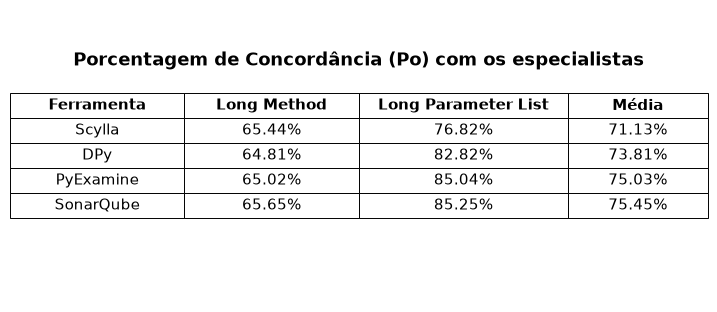

In [138]:
# Criar uma cópia para não alterar o DataFrame original
po_expert_table_display = po_expert_table.copy()

# Renomear a coluna para inglês (mantendo padrão do artigo/relatório)
po_expert_table_display = po_expert_table_display.rename(
    columns={"Ferramenta": "Ferramenta"}
)

# Formatar os valores como porcentagem com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    po_expert_table_display[col] = po_expert_table_display[col].apply(
        lambda x: f"{x * 100:.2f}%"
    )

# Criar a figura
fig, ax = plt.subplots(figsize=(9, 3.8))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Porcentagem de Concordância (Po) com os especialistas", 
    fontsize=13, 
    weight="bold", 
    y=0.78  # Posiciona o título de forma harmônica acima do cabeçalho
)

# Criar a tabela
table = ax.table(
    cellText=po_expert_table_display.values,
    colLabels=po_expert_table_display.columns,
    cellLoc="center",
    loc="center",
    colWidths=[0.25, 0.25, 0.30, 0.20]
)

# Configuração da fonte
table.auto_set_font_size(False)
table.set_fontsize(10.5)

# Altura das linhas
table.scale(1, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Espessura das bordas
for cell in table.get_celld().values():
    cell.set_linewidth(0.7)

# Salvar como JPEG
plt.savefig(
    "percentage_agreement_with_experts.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem para não cortar o título
)

plt.show()

In [106]:
f1_Scylla_LongMethod = f1_score(
    df_experts["expert_long_method"],
    df_Scylla["scylla_long_method"]
)

f1_DPy_LongMethod = f1_score(
    df_experts["expert_long_method"],
    df_DPy["dpy_long_method"]
)

f1_PyExamine_LongMethod = f1_score(
    df_experts["expert_long_method"],
    df_PyExamine["pyexamine_long_method"]
)

f1_SonarQube_LongMethod = f1_score(
    df_experts["expert_long_method"],
    df_SonarQube["sonar_long_method"]
)



f1_Scylla_LongParameterList = f1_score(
    df_experts["expert_long_parameter_list"],
    df_Scylla["scylla_long_parameter_list"]
)

f1_DPy_LongParameterList = f1_score(
    df_experts["expert_long_parameter_list"],
    df_DPy["dpy_long_parameter_list"]
)

f1_PyExamine_LongParameterList = f1_score(
    df_experts["expert_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"]
)

f1_SonarQube_LongParameterList = f1_score(
    df_experts["expert_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"]
)

In [139]:
f1_table = pd.DataFrame({
    "Ferramenta": [
        "Scylla",
        "DPy",
        "PyExamine",
        "SonarQube"
    ],

    "Long Method": [
        f1_Scylla_LongMethod,
        f1_DPy_LongMethod,
        f1_PyExamine_LongMethod,
        f1_SonarQube_LongMethod
    ],

    "Long Parameter List": [
        f1_Scylla_LongParameterList,
        f1_DPy_LongParameterList,
        f1_PyExamine_LongParameterList,
        f1_SonarQube_LongParameterList
    ]
})

# Média dos dois smells
f1_table["Média"] = (
    f1_table["Long Method"] +
    f1_table["Long Parameter List"]
) / 2

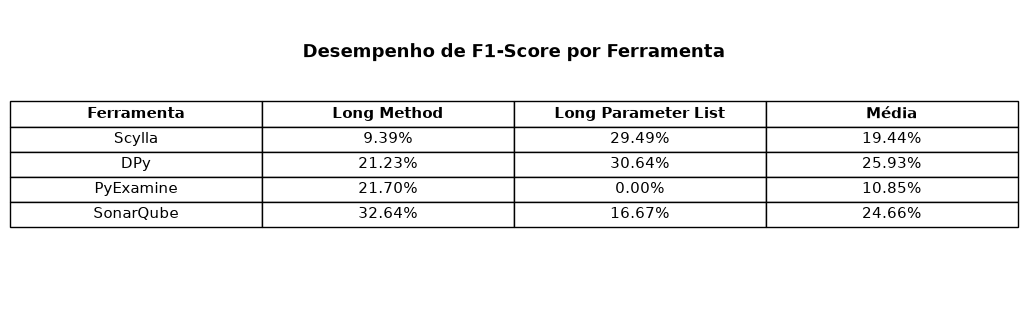

In [140]:

# Criar uma cópia para não alterar o DataFrame original
f1_table_display = f1_table.copy()

# Formatar os valores como porcentagem com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    f1_table_display[col] = f1_table_display[col].apply(
        lambda x: f"{x * 100:.2f}%"
    )

# Criar a figura
fig, ax = plt.subplots(figsize=(10, 4))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Desempenho de F1-Score por Ferramenta", 
    fontsize=13, 
    weight="bold", 
    y=0.82  # Posiciona o título de forma harmônica acima do cabeçalho
)

# Criar a tabela usando TODAS as colunas
table = ax.table(
    cellText=f1_table_display.values,
    colLabels=f1_table_display.columns,
    cellLoc="center",
    loc="center"
)

# Configuração da tabela
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Salvar como JPEG
plt.savefig(
    "f1_score.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem adequada para o título
)

plt.show()

In [109]:
precision_Scylla_LongMethod = precision_score(
    df_experts["expert_long_method"],
    df_Scylla["scylla_long_method"],
    zero_division=0
)

precision_DPy_LongMethod = precision_score(
    df_experts["expert_long_method"],
    df_DPy["dpy_long_method"],
    zero_division=0
)

precision_PyExamine_LongMethod = precision_score(
    df_experts["expert_long_method"],
    df_PyExamine["pyexamine_long_method"],
    zero_division=0
)

precision_SonarQube_LongMethod = precision_score(
    df_experts["expert_long_method"],
    df_SonarQube["sonar_long_method"],
    zero_division=0
)


precision_Scylla_LongParameterList = precision_score(
    df_experts["expert_long_parameter_list"],
    df_Scylla["scylla_long_parameter_list"],
    zero_division=0
)

precision_DPy_LongParameterList = precision_score(
    df_experts["expert_long_parameter_list"],
    df_DPy["dpy_long_parameter_list"],
    zero_division=0
)

precision_PyExamine_LongParameterList = precision_score(
    df_experts["expert_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"],
    zero_division=0
)

precision_SonarQube_LongParameterList = precision_score(
    df_experts["expert_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"],
    zero_division=0
)

In [141]:
precision_table = pd.DataFrame({
    "Ferramenta": [
        "Scylla",
        "DPy",
        "PyExamine",
        "SonarQube"
    ],

    "Long Method": [
        precision_Scylla_LongMethod,
        precision_DPy_LongMethod,
        precision_PyExamine_LongMethod,
        precision_SonarQube_LongMethod
    ],

    "Long Parameter List": [
        precision_Scylla_LongParameterList,
        precision_DPy_LongParameterList,
        precision_PyExamine_LongParameterList,
        precision_SonarQube_LongParameterList
    ]
})

# Média dos dois smells
precision_table["Média"] = (
    precision_table["Long Method"] +
    precision_table["Long Parameter List"]
) / 2

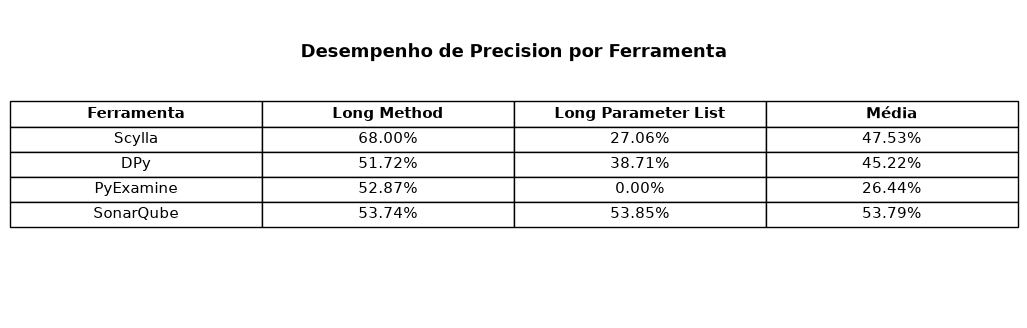

In [142]:
# Criar uma cópia para não alterar o DataFrame original
precision_table_display = precision_table.copy()

# Formatar os valores como porcentagem com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    precision_table_display[col] = precision_table_display[col].apply(
        lambda x: f"{x * 100:.2f}%"
    )

# Criar a figura
fig, ax = plt.subplots(figsize=(10, 4))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Desempenho de Precision por Ferramenta", 
    fontsize=13, 
    weight="bold", 
    y=0.82  # Posiciona o título de forma harmônica acima do cabeçalho
)

# Criar a tabela usando TODAS as colunas
table = ax.table(
    cellText=precision_table_display.values,
    colLabels=precision_table_display.columns,
    cellLoc="center",
    loc="center"
)

# Configuração da tabela
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Salvar como JPEG
plt.savefig(
    "precision_score.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem adequada para o título
)

plt.show()

In [112]:
recall_Scylla_LongMethod = recall_score(
    df_experts["expert_long_method"],
    df_Scylla["scylla_long_method"],
    zero_division=0
)

recall_DPy_LongMethod = recall_score(
    df_experts["expert_long_method"],
    df_DPy["dpy_long_method"],
    zero_division=0
)

recall_PyExamine_LongMethod = recall_score(
    df_experts["expert_long_method"],
    df_PyExamine["pyexamine_long_method"],
    zero_division=0
)

recall_SonarQube_LongMethod = recall_score(
    df_experts["expert_long_method"],
    df_SonarQube["sonar_long_method"],
    zero_division=0
)


recall_Scylla_LongParameterList = recall_score(
    df_experts["expert_long_parameter_list"],
    df_Scylla["scylla_long_parameter_list"],
    zero_division=0
)

recall_DPy_LongParameterList = recall_score(
    df_experts["expert_long_parameter_list"],
    df_DPy["dpy_long_parameter_list"],
    zero_division=0
)

recall_PyExamine_LongParameterList = recall_score(
    df_experts["expert_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"],
    zero_division=0
)

recall_SonarQube_LongParameterList = recall_score(
    df_experts["expert_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"],
    zero_division=0
)

In [146]:
recall_table = pd.DataFrame({
    "Ferramenta": [
        "Scylla",
        "DPy",
        "PyExamine",
        "SonarQube"
    ],

    "Long Method": [
        recall_Scylla_LongMethod,
        recall_DPy_LongMethod,
        recall_PyExamine_LongMethod,
        recall_SonarQube_LongMethod
    ],

    "Long Parameter List": [
        recall_Scylla_LongParameterList,
        recall_DPy_LongParameterList,
        recall_PyExamine_LongParameterList,
        recall_SonarQube_LongParameterList
    ]
})

# Média dos dois smells
recall_table["Média"] = (
    recall_table["Long Method"] +
    recall_table["Long Parameter List"]
) / 2

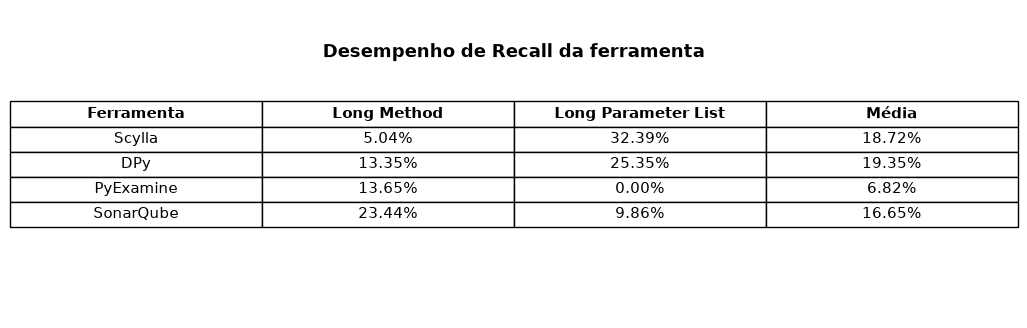

In [147]:
# Criar uma cópia para não alterar o DataFrame original
recall_table_display = recall_table.copy()

# Formatar os valores como porcentagem com 2 casas decimais
for col in ["Long Method", "Long Parameter List", "Média"]:
    recall_table_display[col] = recall_table_display[col].apply(
        lambda x: f"{x * 100:.2f}%"
    )

# Criar a figura
fig, ax = plt.subplots(figsize=(10, 4))

ax.axis("off")

# --- ADIÇÃO DO TÍTULO ---
ax.set_title(
    "Desempenho de Recall da ferramenta", 
    fontsize=13, 
    weight="bold", 
    y=0.82  # Posiciona o título de forma harmônica acima do cabeçalho
)

# Criar a tabela usando TODAS as colunas
table = ax.table(
    cellText=recall_table_display.values,
    colLabels=recall_table_display.columns,
    cellLoc="center",
    loc="center"
)

# Configuração da tabela
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.5)

# Cabeçalho em negrito
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")

# Salvar como JPEG
plt.savefig(
    "recall_score.jpeg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15  # Garante margem adequada para o título
)

plt.show()

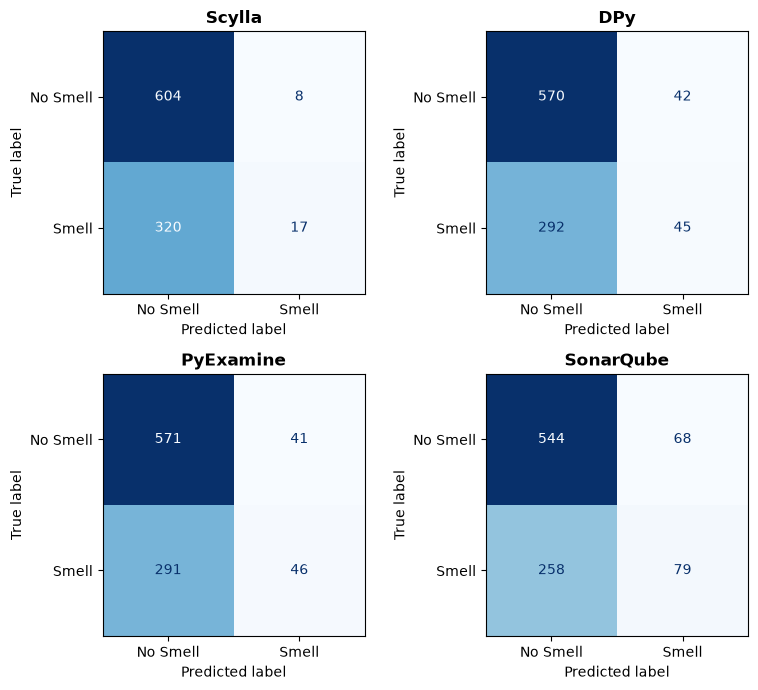

In [115]:
# Criar as matrizes de confusão
cm_scylla = confusion_matrix(
    df_experts["expert_long_method"],
    df_Scylla["scylla_long_method"]
)

cm_dpy = confusion_matrix(
    df_experts["expert_long_method"],
    df_DPy["dpy_long_method"]
)

cm_pyexamine = confusion_matrix(
    df_experts["expert_long_method"],
    df_PyExamine["pyexamine_long_method"]
)

cm_sonarqube = confusion_matrix(
    df_experts["expert_long_method"],
    df_SonarQube["sonar_long_method"]
)


# Criar grid 2x2
fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7)
)

# Matriz 1 - Scylla
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_scylla,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[0, 0],
    cmap="Blues",
    colorbar=False
)

axes[0, 0].set_title("Scylla", fontsize=12, fontweight="bold")


# Matriz 2 - DPy
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dpy,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[0, 1],
    cmap="Blues",
    colorbar=False
)

axes[0, 1].set_title("DPy", fontsize=12, fontweight="bold")


# Matriz 3 - PyExamine
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pyexamine,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[1, 0],
    cmap="Blues",
    colorbar=False
)

axes[1, 0].set_title("PyExamine", fontsize=12, fontweight="bold")


# Matriz 4 - SonarQube
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sonarqube,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[1, 1],
    cmap="Blues",
    colorbar=False
)

axes[1, 1].set_title("SonarQube", fontsize=12, fontweight="bold")


# Ajustar espaçamento
plt.tight_layout()

# Salvar como JPEG
plt.savefig(
    "confusion_matrix_long_method.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

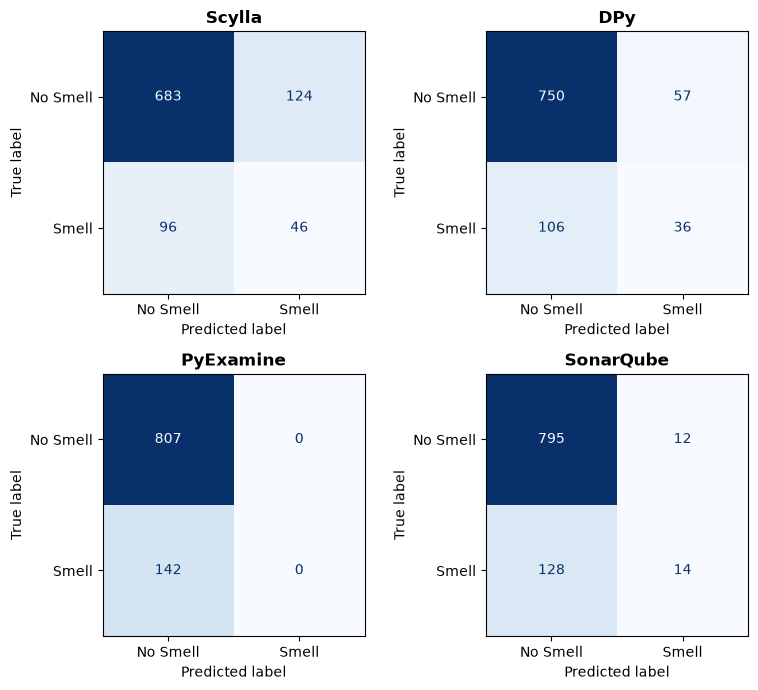

In [116]:
# Criar as matrizes de confusão
cm_scylla = confusion_matrix(
    df_experts["expert_long_parameter_list"],
    df_Scylla["scylla_long_parameter_list"]
)

cm_dpy = confusion_matrix(
    df_experts["expert_long_parameter_list"],
    df_DPy["dpy_long_parameter_list"]
)

cm_pyexamine = confusion_matrix(
    df_experts["expert_long_parameter_list"],
    df_PyExamine["pyexamine_long_parameter_list"]
)

cm_sonarqube = confusion_matrix(
    df_experts["expert_long_parameter_list"],
    df_SonarQube["sonar_long_parameter_list"]
)


# Criar grid 2x2
fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7)
)

# Matriz 1 - Scylla
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_scylla,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[0, 0],
    cmap="Blues",
    colorbar=False
)

axes[0, 0].set_title("Scylla", fontsize=12, fontweight="bold")


# Matriz 2 - DPy
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dpy,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[0, 1],
    cmap="Blues",
    colorbar=False
)

axes[0, 1].set_title("DPy", fontsize=12, fontweight="bold")


# Matriz 3 - PyExamine
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pyexamine,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[1, 0],
    cmap="Blues",
    colorbar=False
)

axes[1, 0].set_title("PyExamine", fontsize=12, fontweight="bold")


# Matriz 4 - SonarQube
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sonarqube,
    display_labels=["No Smell", "Smell"]
)

disp.plot(
    ax=axes[1, 1],
    cmap="Blues",
    colorbar=False
)

axes[1, 1].set_title("SonarQube", fontsize=12, fontweight="bold")


# Ajustar espaçamento
plt.tight_layout()

# Salvar como JPEG
plt.savefig(
    "confusion_matrix_long_parameter_list.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()